In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

df = df.drop(columns=["deck"])

df["age"] = df["age"].fillna(df["age"].median())

df = df.dropna(subset=["embarked", "embark_town"])

print("Cleaned shape:", df.shape)

Dataset loaded successfully.
Original shape: (891, 15)
Cleaned shape: (889, 14)


In [3]:
X = df.drop(columns=["survived"])
y = df["survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nOverall class distribution:")
print(y.value_counts())

print("\nOverall class proportions:")
print(y.value_counts(normalize=True))

Features shape: (889, 13)
Target shape: (889,)

Overall class distribution:
survived
0    549
1    340
Name: count, dtype: int64

Overall class proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.20,random_state=42,stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape    :", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Training set shape: (711, 13)
Test set shape    : (178, 13)

Training class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Test class proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully.
Numeric features: ['age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)
decision_tree_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

print("All three classifiers trained successfully.")

All three classifiers trained successfully.


In [7]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = decision_tree_pipeline.predict(X_test)
y_pred_forest = random_forest_pipeline.predict(X_test)

print("Predictions generated successfully.")

print("\nSample Logistic Regression predictions:")
print(y_pred_logistic[:10])

print("\nSample Decision Tree predictions:")
print(y_pred_tree[:10])

print("\nSample Random Forest predictions:")
print(y_pred_forest[:10])

Predictions generated successfully.

Sample Logistic Regression predictions:
[0 0 0 0 0 1 0 1 1 0]

Sample Decision Tree predictions:
[0 0 0 0 0 1 0 1 1 0]

Sample Random Forest predictions:
[0 0 0 0 0 1 0 1 0 0]



========== Logistic Regression ==========
Confusion Matrix:
[[96 14]
 [25 43]]
Accuracy : 0.7809
Precision: 0.7544
Recall   : 0.6324
F1 Score : 0.6880
ROC-AUC  : 0.8265


<Figure size 900x700 with 0 Axes>

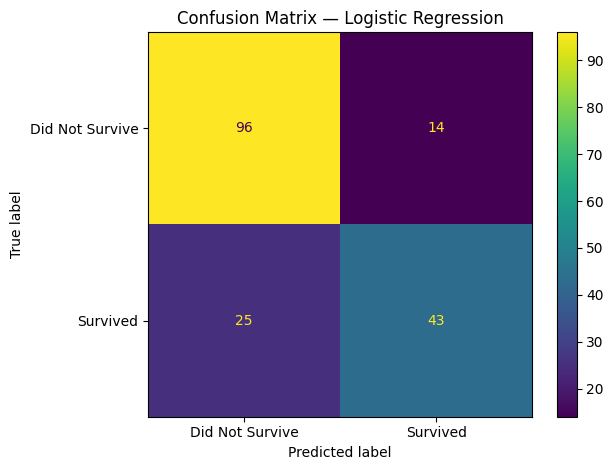


========== Decision Tree ==========
Confusion Matrix:
[[97 13]
 [20 48]]
Accuracy : 0.8146
Precision: 0.7869
Recall   : 0.7059
F1 Score : 0.7442
ROC-AUC  : 0.8207


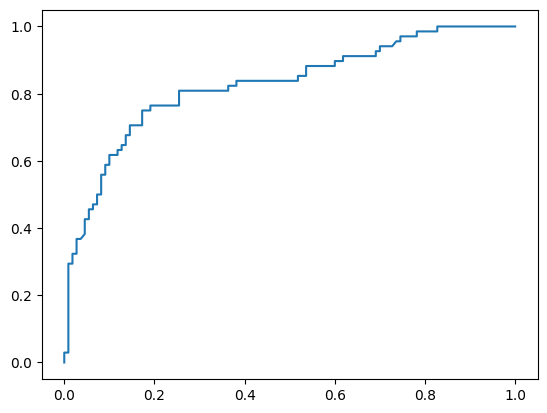

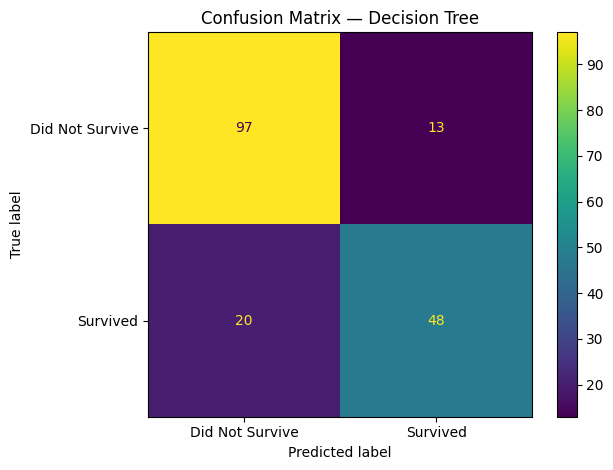


========== Random Forest ==========
Confusion Matrix:
[[97 13]
 [23 45]]
Accuracy : 0.7978
Precision: 0.7759
Recall   : 0.6618
F1 Score : 0.7143
ROC-AUC  : 0.8211


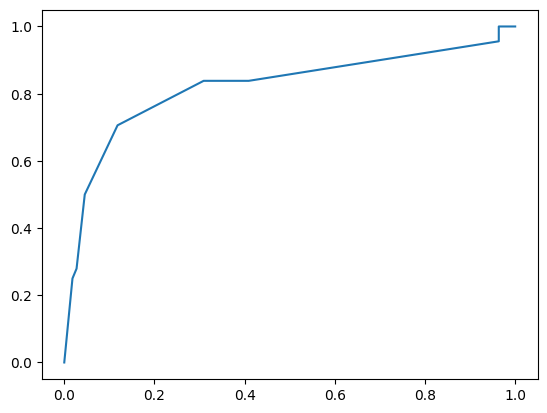

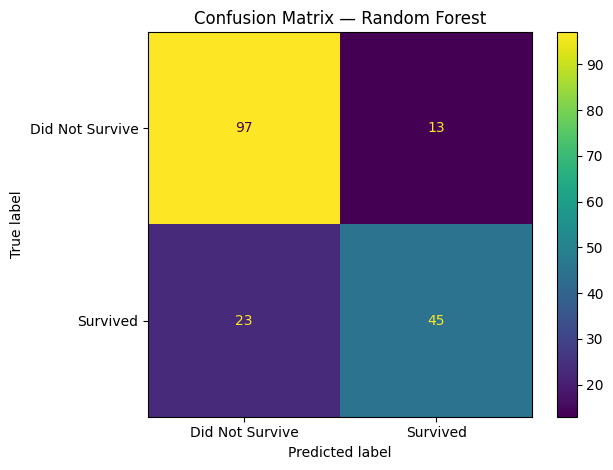

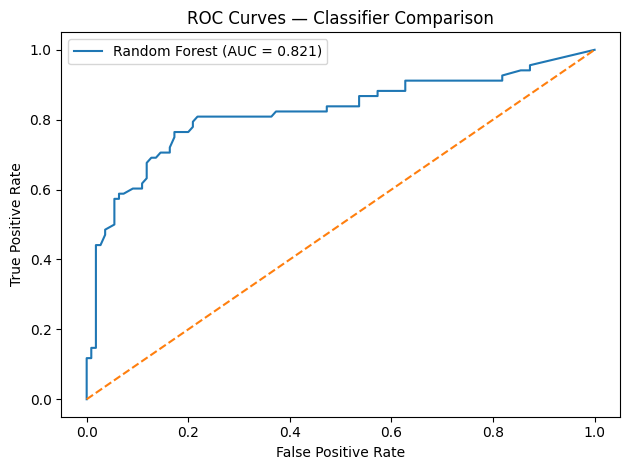


========== CLASSIFIER COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.7809,0.7544,0.6324,0.6880,0.8265
1,Decision Tree,0.8146,0.7869,0.7059,0.7442,0.8207
2,Random Forest,0.7978,0.7759,0.6618,0.7143,0.8211


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix,accuracy_score,precision_score,
    recall_score, f1_score,roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": (logistic_pipeline, y_pred_logistic),
    "Decision Tree": (decision_tree_pipeline, y_pred_tree),
    "Random Forest": (random_forest_pipeline, y_pred_forest)
}

results = []

plt.figure(figsize=(9, 7))

for model_name, (model, y_pred) in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n========== {model_name} ==========")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Did Not Survive", "Survived"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison")
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)

print("\n========== CLASSIFIER COMPARISON ==========")
display(results_df.round(4))

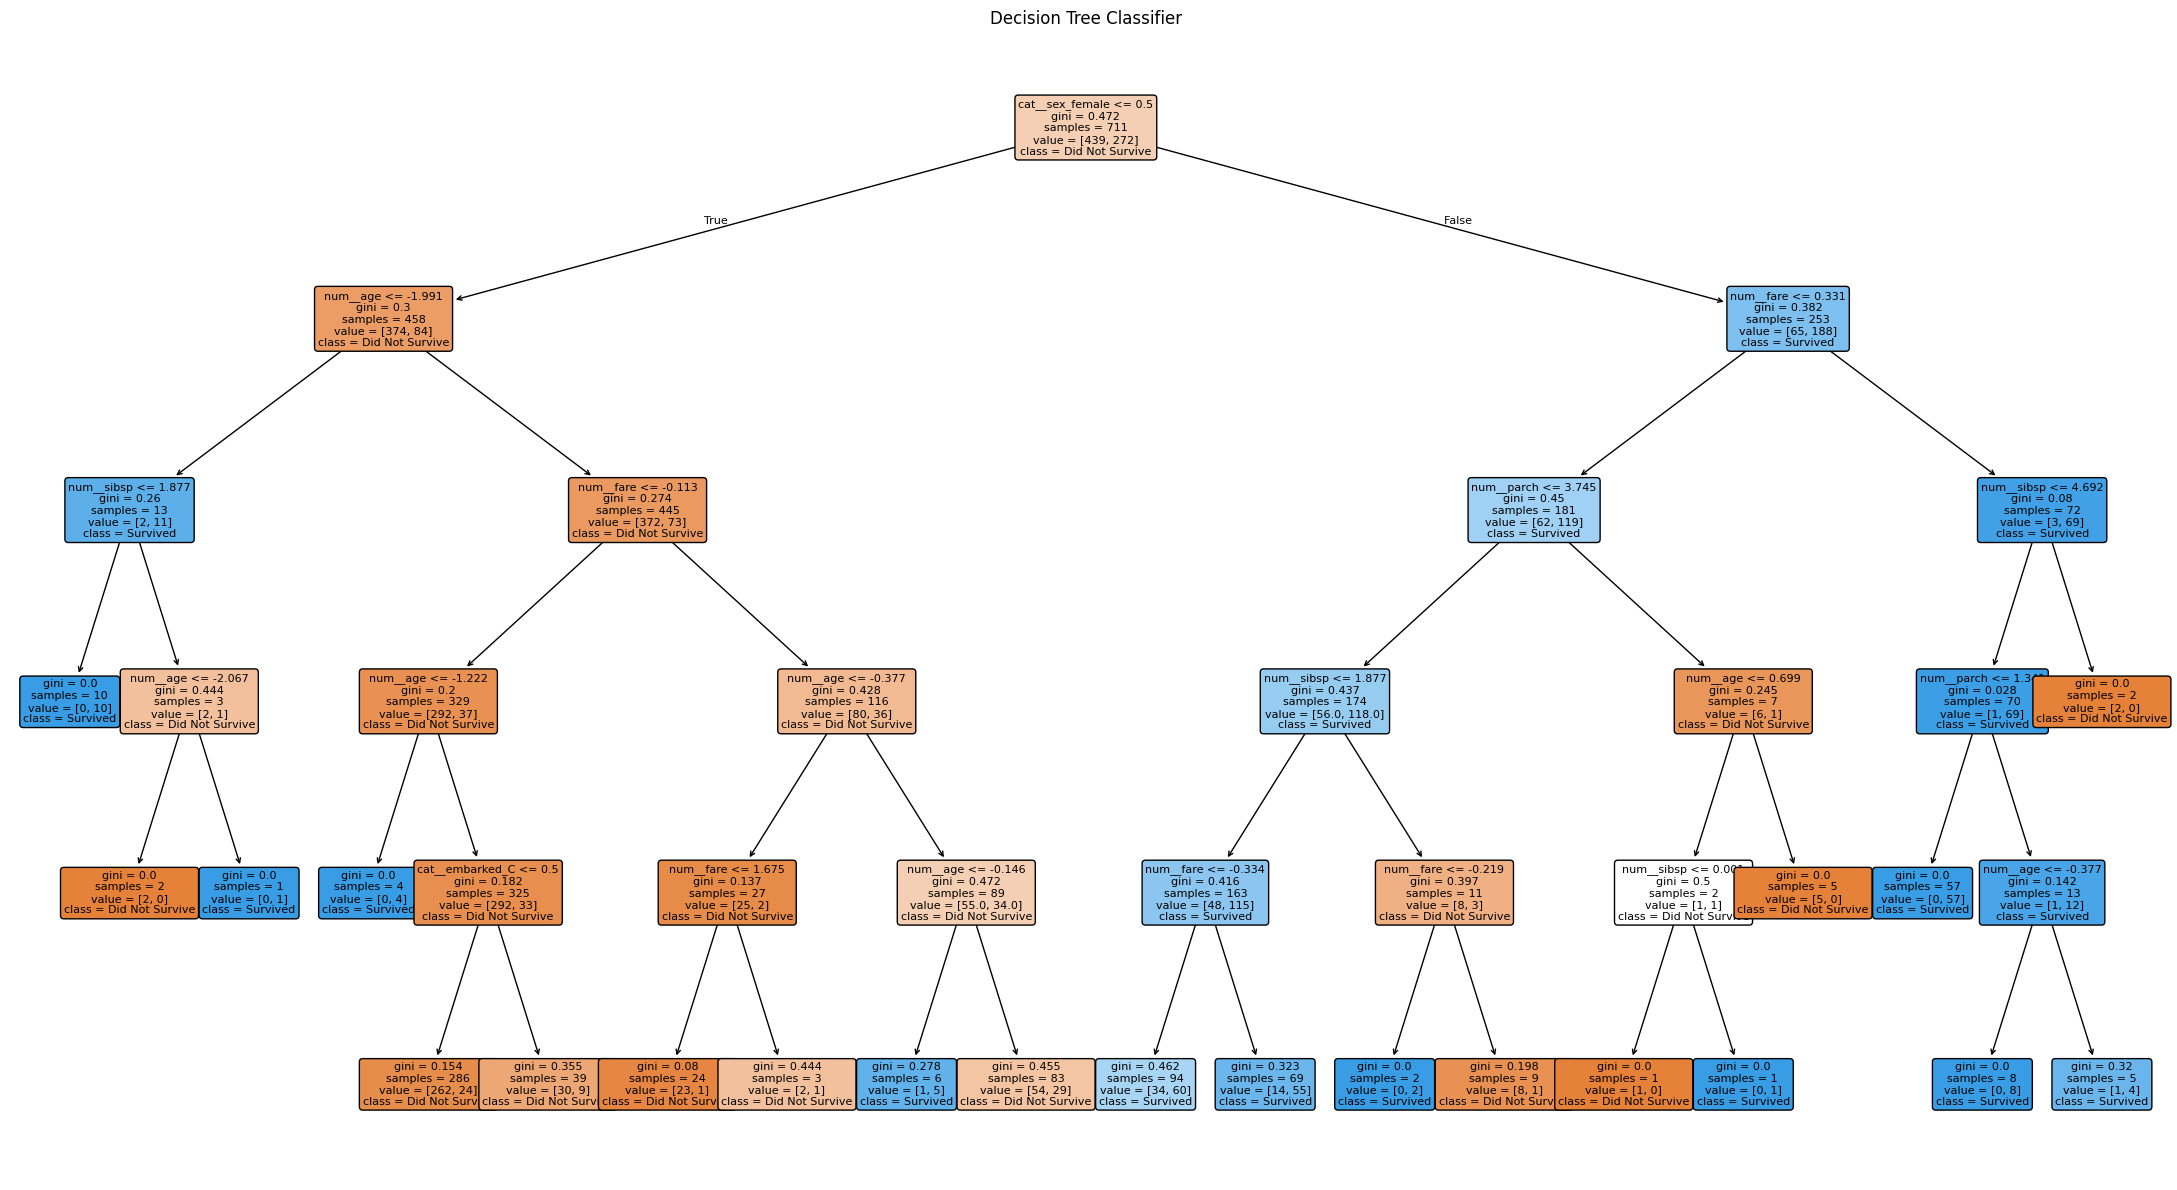

In [10]:
from sklearn.tree import plot_tree

fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
fitted_tree = decision_tree_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()

### Class Imbalance Analysis

The target class distribution was examined before training the three approaches. The baseline Logistic Regression model represents the standard approach, while `class_weight="balanced"` gives greater weight to the minority class during training. SMOTE creates synthetic minority-class training samples and is applied only to the training data so that information from the test set is not used during resampling.

The three approaches are compared using precision, recall, and F1-score. The observed metric differences will be used to explain how class-imbalance handling changes the model's ability to identify the positive class.

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Baseline Logistic Regression

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)


# 2. Logistic Regression with class_weight="balanced"

balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)


# 3. Logistic Regression + SMOTE

smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_test)


# Compare metrics

imbalance_results = []

for name, y_pred in [
    ("Baseline", baseline_pred),
    ("Class Weight Balanced", balanced_pred),
    ("SMOTE", smote_pred)
]:
    imbalance_results.append({
        "Method": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

imbalance_results_df = pd.DataFrame(imbalance_results)

print("========== CLASS IMBALANCE COMPARISON ==========")
display(imbalance_results_df.round(4))

========== CLASS IMBALANCE COMPARISON ==========


,Method,Precision,Recall,F1
0,Baseline,0.7544,0.6324,0.6880
1,Class Weight Balanced,0.7500,0.7059,0.7273
2,SMOTE,0.7460,0.6912,0.7176


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        oob_score=True,
        random_state=42,
        bootstrap=True
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("========== RANDOM FOREST GRID SEARCH ==========")
print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{rf_grid.best_score_:.4f}")

best_rf_pipeline = rf_grid.best_estimator_
best_rf = best_rf_pipeline.named_steps["classifier"]

print("\nOOB Score:")
print(f"{best_rf.oob_score_:.4f}")

========== RANDOM FOREST GRID SEARCH ==========
Best parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best cross-validation ROC-AUC:
0.8586

OOB Score:
0.8073


Regression numeric features: ['survived', 'pclass', 'age', 'sibsp', 'parch']
Regression categorical features: ['sex', 'embarked', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

========== REGRESSION RESULTS ==========
MAE        : 21.2234
RMSE       : 42.4276
R²         : 0.3253
Adjusted R²: 0.2295


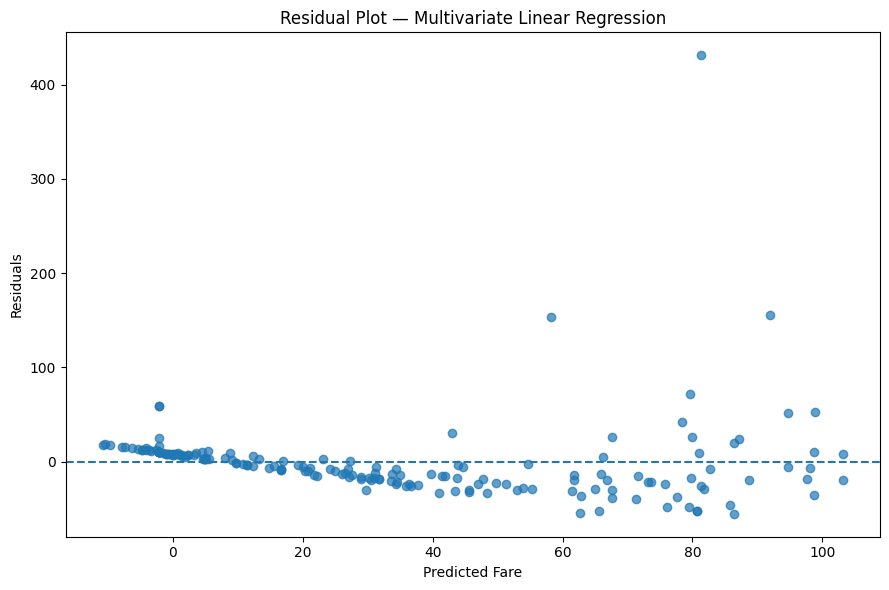

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


reg_df = df.copy()

X_reg = reg_df.drop(columns=["fare"])
y_reg = reg_df["fare"]

X_reg = X_reg.drop(columns=["class"])

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

reg_numeric_features = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
reg_categorical_features = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Regression numeric features:", reg_numeric_features)
print("Regression categorical features:", reg_categorical_features)


reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", reg_numeric_pipeline, reg_numeric_features),
    ("cat", reg_categorical_pipeline, reg_categorical_features)
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = regression_pipeline.named_steps["preprocessor"].transform(
    X_reg_test.iloc[:1]
).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n========== REGRESSION RESULTS ==========")
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R²         : {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_reg_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Multivariate Linear Regression")
plt.tight_layout()
plt.show()

### Residual Analysis and Heteroscedasticity

The residual plot shows that the residuals are not evenly distributed across the range of predicted fare values. The spread of residuals becomes wider for larger predicted fares, indicating the presence of heteroscedasticity. This suggests that the variance of the regression errors is not constant across the predictions.

In [14]:
print("========== CLASSIFIER METRICS ==========")
display(results_df.round(4))

print("\n========== REGRESSION METRICS ==========")

regression_results_df = pd.DataFrame([{
    "Model": "Multivariate Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2
}])

display(regression_results_df.round(4))

========== CLASSIFIER METRICS ==========


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.7809,0.7544,0.6324,0.6880,0.8265
1,Decision Tree,0.8146,0.7869,0.7059,0.7442,0.8207
2,Random Forest,0.7978,0.7759,0.6618,0.7143,0.8211



========== REGRESSION METRICS ==========


,Model,MAE,RMSE,R2,Adjusted_R2
0,Multivariate Linear Regression,21.2234,42.4276,0.3253,0.2295


In [16]:
import joblib


final_pipeline = decision_tree_pipeline

model_path = "titanic_best_pipeline.joblib"
joblib.dump(final_pipeline, model_path)

print("Pipeline saved successfully:")
print(model_path)


loaded_pipeline = joblib.load(model_path)

print("\nPipeline reloaded successfully.")


raw_test_samples = X_test.head(5)

predictions = loaded_pipeline.predict(raw_test_samples)

print("\nRaw input samples:")
display(raw_test_samples)

print("\nPredictions from reloaded pipeline:")
print(predictions)

Pipeline saved successfully:
titanic_best_pipeline.joblib

Pipeline reloaded successfully.

Raw input samples:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
160,3,male,44.0,0,1,16.100,S,Third,man,True,Southampton,no,False
126,3,male,28.0,0,0,7.750,Q,Third,man,True,Queenstown,no,True
428,3,male,28.0,0,0,7.750,Q,Third,man,True,Queenstown,no,True
422,3,male,29.0,0,0,7.875,S,Third,man,True,Southampton,no,True
565,3,male,24.0,2,0,24.150,S,Third,man,True,Southampton,no,False



Predictions from reloaded pipeline:
[0 0 0 0 0]


In [ ]:
# Compare predictions with the actual survival values

actual_values = y_test.loc[raw_test_samples.index].values

print("Predicted:", predictions)
print("Actual   :", actual_values)

print("\nCorrect predictions:", predictions == actual_values)
print("Number correct:", (predictions == actual_values).sum(), "out of", len(actual_values))

Predicted: [0 0 0 0 0]
Actual   : [0 0 0 0 0]

Correct predictions: [ True  True  True  True  True]
Number correct: 5 out of 5


: 